# 👩‍💻 **Compare Outputs from GAN, VAE, and Diffusion Models**

**Time Estimate:** 60 minutes

## 📋 **Overview**

In this activity, you'll compare the outputs of Generative Adversarial Networks (GANs), Variational Autoencoders (VAEs), and Diffusion Models. This exercise aims to deepen your understanding of the differences in output quality, diversity, and stability among these models. Such insights are crucial for selecting the right generative model for specific real-world applications in creative studios, data science, and AI development.

## 🎯 **Learning Outcomes**

By the end of this lab, you will be able to:

- Analyze the quality of outputs generated by GANs, VAEs, and Diffusion Models.
- Identify differences in output diversity and stability across models.
- Reflect on the applicability of each model type for various use cases.

## Task 1: VAE Implementation and Analysis [20 minutes]

In [1]:
# imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.datasets import make_classification
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

1. Set up a Variational Autoencoder (VAE) for anomaly detection using ECG data.
2. Train the VAE model and evaluate its reconstruction capabilities.
3. Generate reconstruction examples to assess VAE output quality.

Normal data shape: (1000, 100)
Anomaly data shape: (100, 100)
Normal scaled shape: (1000, 100)
Anomaly scaled shape: (100, 100)


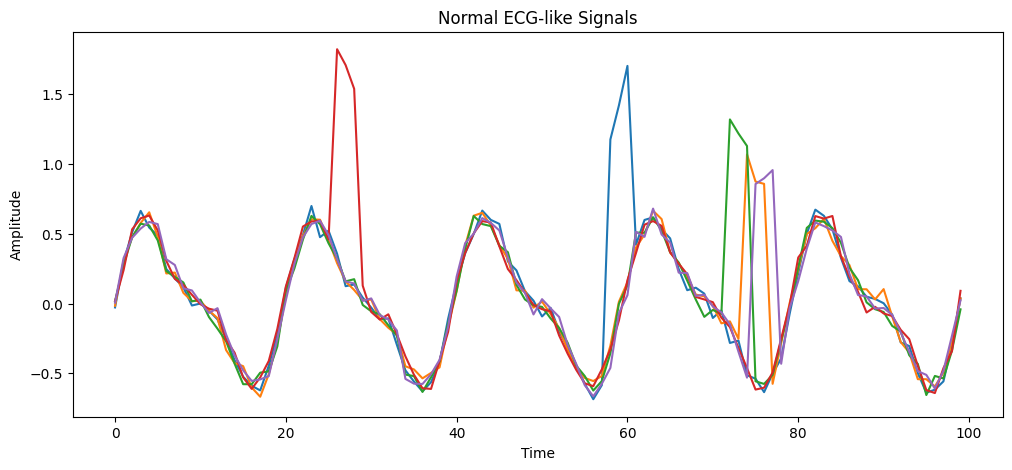

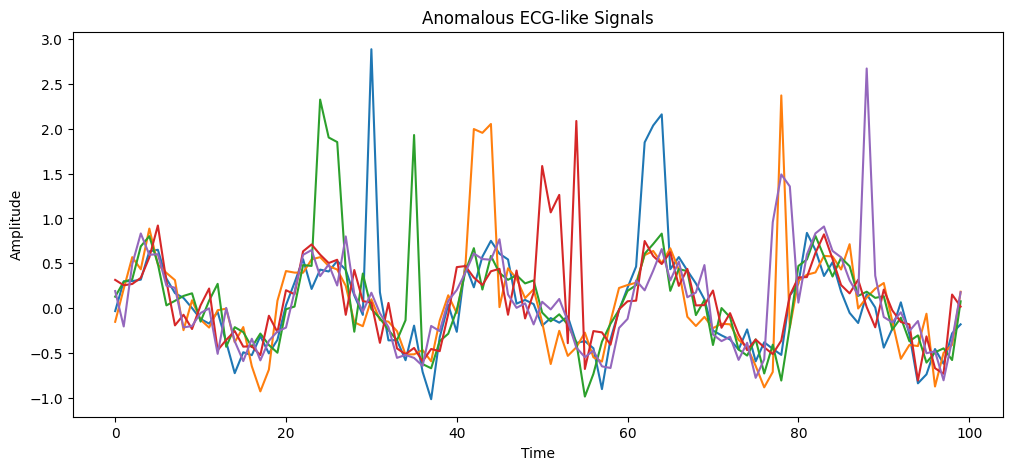

Training data: torch.Size([1000, 100])
Anomaly data: torch.Size([100, 100])
VAE(
  (encoder): Sequential(
    (0): Linear(in_features=100, out_features=64, bias=True)
    (1): ReLU()
  )
  (fc_mu): Linear(in_features=64, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=64, out_features=16, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=100, bias=True)
  )
)
Epoch [10/100] Loss: 1.0496 Recon: 1.0284 KL: 0.0212
Epoch [20/100] Loss: 1.0278 Recon: 1.0157 KL: 0.0121
Epoch [30/100] Loss: 1.0199 Recon: 1.0115 KL: 0.0085
Epoch [40/100] Loss: 1.0139 Recon: 1.0077 KL: 0.0062
Epoch [50/100] Loss: 1.0115 Recon: 1.0067 KL: 0.0048
Epoch [60/100] Loss: 1.0091 Recon: 1.0053 KL: 0.0039
Epoch [70/100] Loss: 1.0082 Recon: 1.0050 KL: 0.0032
Epoch [80/100] Loss: 1.0065 Recon: 1.0038 KL: 0.0027
Epoch [90/100] Loss: 1.0059 Recon: 1.0036 KL: 0.0024
Epoch [100/100] Loss: 1.0046 Recon: 1.00

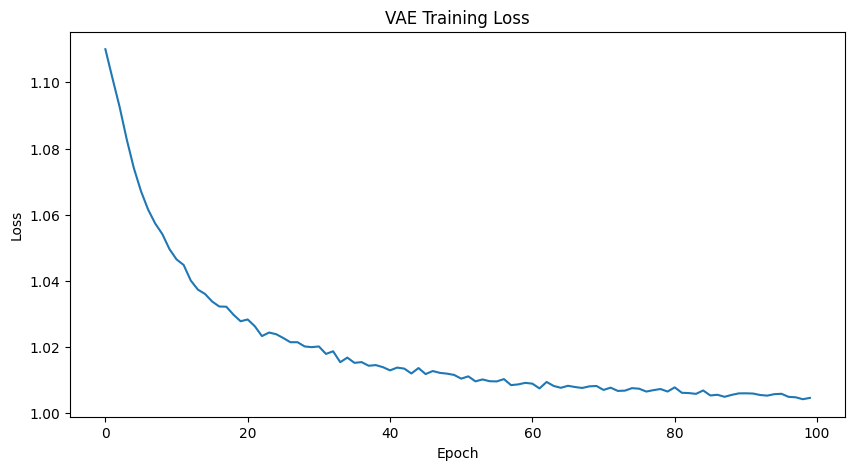

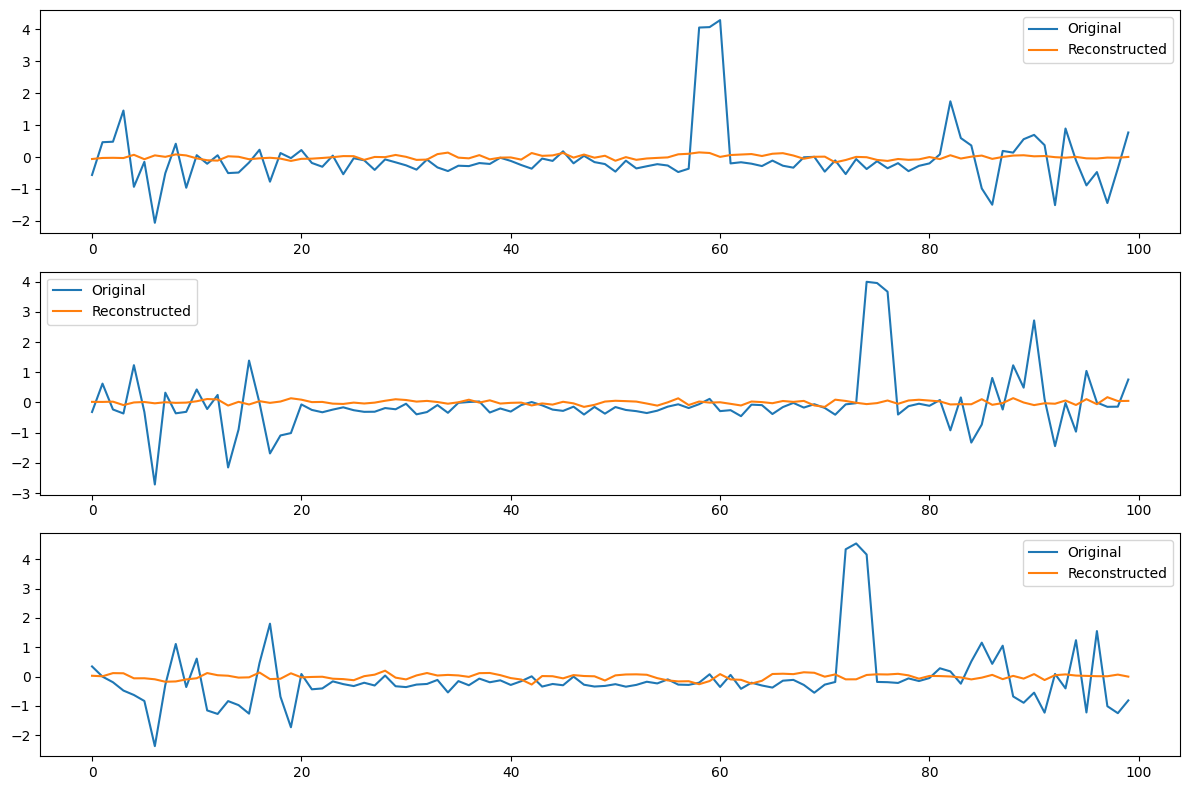

Average normal reconstruction error:
1.0029590095555598
Average anomaly reconstruction error:
16.557411839215103


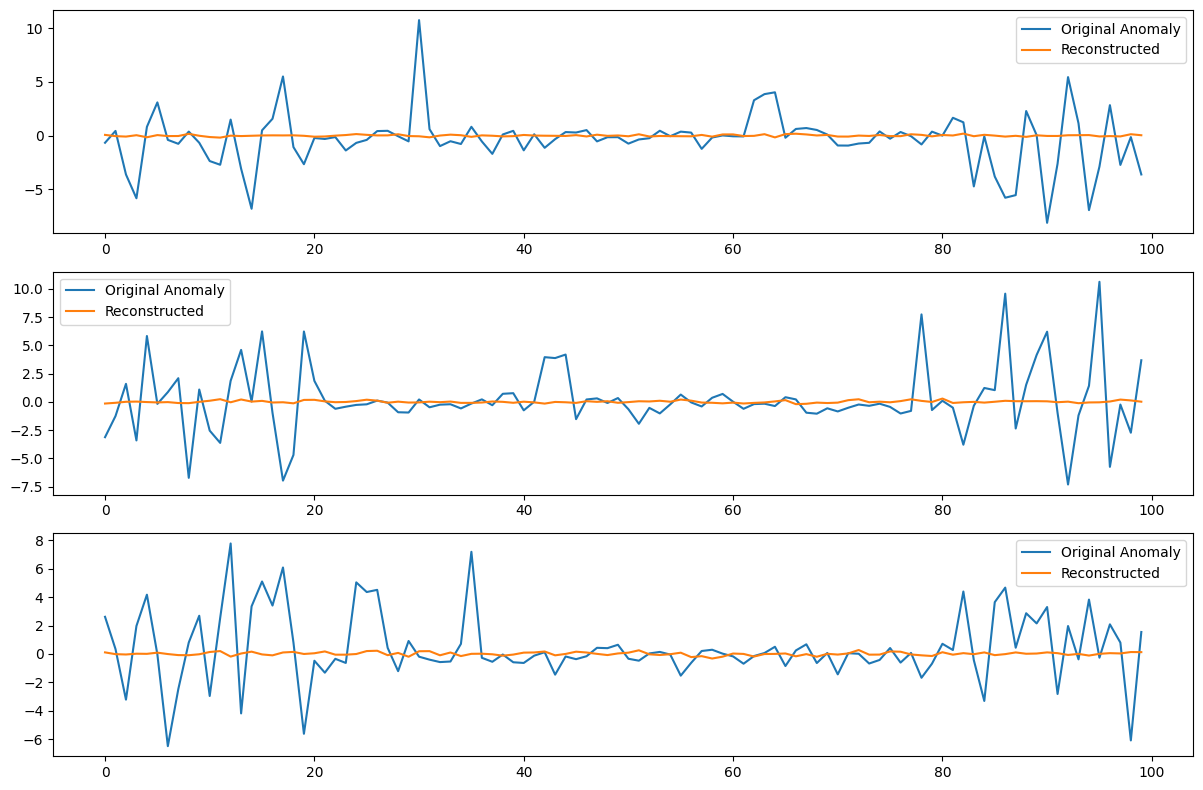

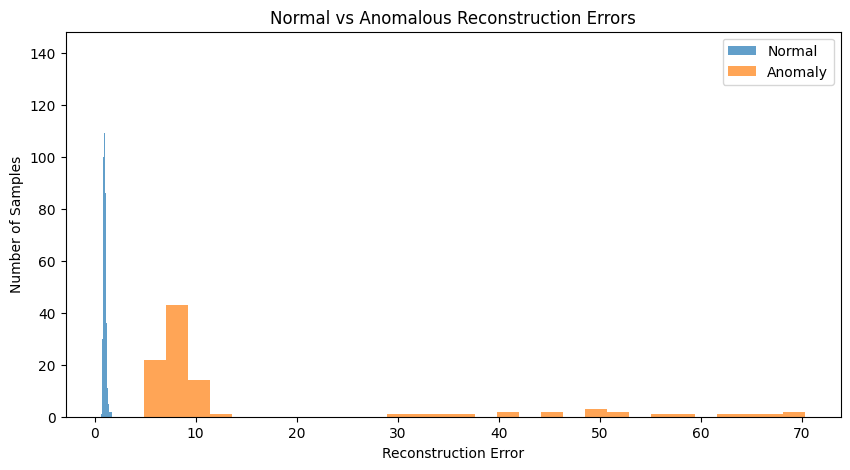

Anomaly threshold: 1.2594917963452736
Detected anomalies: 100
Total anomalies: 100


In [5]:
# Create synthetic ECG-like data

np.random.seed(42)
torch.manual_seed(42)

n_samples = 1000
sequence_length = 100

t = np.linspace(0, 1, sequence_length)

normal_data = []

for i in range(n_samples):
    signal = (
        0.5 * np.sin(2 * np.pi * 5 * t)
        + 0.2 * np.sin(2 * np.pi * 10 * t)
    )
    
    peak_position = np.random.randint(20, 80)
    signal[peak_position:peak_position + 3] += 1.5
    
    signal += np.random.normal(0, 0.05, sequence_length)
    
    normal_data.append(signal)

normal_data = np.array(normal_data)

# Create anomalous ECG samples

n_anomalies = 100

anomaly_data = []

for i in range(n_anomalies):
    signal = (
        0.5 * np.sin(2 * np.pi * 5 * t)
        + 0.2 * np.sin(2 * np.pi * 10 * t)
    )
    
    peak_position = np.random.randint(20, 80)
    signal[peak_position:peak_position + 3] += 1.5
    
    # Add abnormal noise
    signal += np.random.normal(0, 0.2, sequence_length)
    
    # Add abnormal spike
    abnormal_position = np.random.randint(10, 90)
    signal[abnormal_position] += np.random.uniform(2, 4)
    
    anomaly_data.append(signal)

anomaly_data = np.array(anomaly_data)


print("Normal data shape:", normal_data.shape)
print("Anomaly data shape:", anomaly_data.shape)

scaler = StandardScaler()

normal_data_scaled = scaler.fit_transform(normal_data)
anomaly_data_scaled = scaler.transform(anomaly_data)

print("Normal scaled shape:", normal_data_scaled.shape)
print("Anomaly scaled shape:", anomaly_data_scaled.shape)

plt.figure(figsize=(12, 5))

for i in range(5):
    plt.plot(normal_data[i])

plt.title("Normal ECG-like Signals")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

plt.figure(figsize=(12, 5))

for i in range(5):
    plt.plot(anomaly_data[i])

plt.title("Anomalous ECG-like Signals")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

X_train = torch.tensor(
    normal_data_scaled,
    dtype=torch.float32
).to(device)

X_anomaly = torch.tensor(
    anomaly_data_scaled,
    dtype=torch.float32
).to(device)

print("Training data:", X_train.shape)
print("Anomaly data:", X_anomaly.shape)

class VAE(nn.Module):

    def __init__(self, input_dim=100, hidden_dim=64, latent_dim=16):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )

        # Mean of latent distribution
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)

        # Log variance of latent distribution
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)

        epsilon = torch.randn_like(std)

        z = mu + epsilon * std

        return z

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        reconstruction = self.decode(z)

        return reconstruction, mu, logvar
    
    
def vae_loss(reconstruction, x, mu, logvar):

    reconstruction_loss = F.mse_loss(
        reconstruction,
        x,
        reduction="mean"
    )

    kl_loss = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total_loss = reconstruction_loss + kl_loss

    return total_loss, reconstruction_loss, kl_loss

model = VAE(
    input_dim=100,
    hidden_dim=64,
    latent_dim=16
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

epochs = 100

losses = []

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    reconstruction, mu, logvar = model(X_train)

    loss, reconstruction_loss, kl_loss = vae_loss(
        reconstruction,
        X_train,
        mu,
        logvar
    )

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Loss: {loss.item():.4f} "
            f"Recon: {reconstruction_loss.item():.4f} "
            f"KL: {kl_loss.item():.4f}"
        )
        
        
plt.figure(figsize=(10, 5))

plt.plot(losses)

plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()


model.eval()

with torch.no_grad():

    normal_reconstruction, _, _ = model(X_train)

normal_reconstruction = normal_reconstruction.cpu().numpy()

plt.figure(figsize=(12, 8))

for i in range(3):

    plt.subplot(3, 1, i + 1)

    plt.plot(
        normal_data_scaled[i],
        label="Original"
    )

    plt.plot(
        normal_reconstruction[i],
        label="Reconstructed"
    )

    plt.legend()

plt.tight_layout()
plt.show()

normal_errors = np.mean(
    (normal_data_scaled - normal_reconstruction) ** 2,
    axis=1
)

print("Average normal reconstruction error:")
print(normal_errors.mean())

model.eval()

with torch.no_grad():

    anomaly_reconstruction, _, _ = model(X_anomaly)

anomaly_reconstruction = anomaly_reconstruction.cpu().numpy()

anomaly_errors = np.mean(
    (anomaly_data_scaled - anomaly_reconstruction) ** 2,
    axis=1
)

print("Average anomaly reconstruction error:")
print(anomaly_errors.mean())

plt.figure(figsize=(12, 8))

for i in range(3):

    plt.subplot(3, 1, i + 1)

    plt.plot(
        anomaly_data_scaled[i],
        label="Original Anomaly"
    )

    plt.plot(
        anomaly_reconstruction[i],
        label="Reconstructed"
    )

    plt.legend()

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))

plt.hist(
    normal_errors,
    bins=30,
    alpha=0.7,
    label="Normal"
)

plt.hist(
    anomaly_errors,
    bins=30,
    alpha=0.7,
    label="Anomaly"
)

plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Normal vs Anomalous Reconstruction Errors")

plt.legend()

plt.show()

threshold = np.percentile(
    normal_errors,
    95
)

print("Anomaly threshold:", threshold)

predictions = anomaly_errors > threshold

print("Detected anomalies:", predictions.sum())
print("Total anomalies:", len(predictions))


🔍 **Practice**

Examine the VAE reconstruction results. Consider:

- How well the VAE reconstructs normal vs. anomalous data.
- The reconstruction error patterns and their distribution.

✅ **Success Checklist**

- VAE model is properly defined with encoder and decoder components.
- Model training completes without errors and shows decreasing loss.
- Reconstruction examples demonstrate VAE's ability to capture data patterns.

💡 **Key Points**

- VAEs use a probabilistic encoder to map inputs to a latent distribution.
- The reparameterization trick enables backpropagation through stochastic sampling.
- VAE loss combines reconstruction error and KL divergence.

❗ **Common Mistakes to Avoid**

- Failing to properly configure model settings, leading to inaccuracies.
- Not verifying model dependencies, which could prevent successful execution.
- Forgetting to normalize input data before training.

## Task 2: GAN Implementation and Training [20 minutes]
Implement a Generative Adversarial Network (GAN) for data augmentation.
1. Create an imbalanced dataset suitable for GAN training.
2. Define Generator and Discriminator networks.
3. Train the GAN and generate synthetic samples to balance the dataset.
4. Visualize the quality and diversity of GAN-generated samples.

Dataset shape: (1000, 2)
Class 0: 895
Class 1: 105


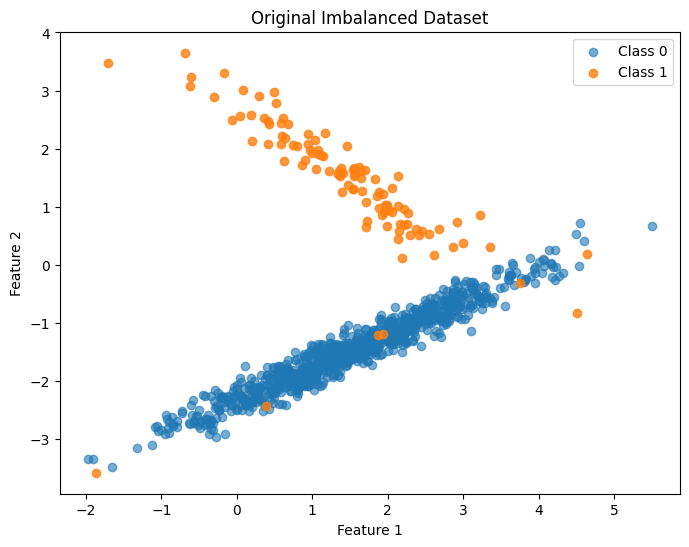

Minority data shape: (105, 2)
Scaled minority data shape: (105, 2)
torch.Size([105, 2])
Generator(
  (model): Sequential(
    (0): Linear(in_features=10, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)
Discriminator(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)
Epoch [200/2000] D Loss: 1.2676 G Loss: 0.7727
Epoch [400/2000] D Loss: 1.1163 G Loss: 1.0463
Epoch [600/2000] D Loss: 1.2624 G Loss: 0.8450
Epoch [800/2000] D Loss: 1.4480 G Loss: 0.6663
Epoch [1000/2000] D Loss: 1.4289 G Loss: 0.6771
Epoch [1200/2000] D Loss: 1.3867 G Loss: 0.6966
Epoch [1400/2000] D Loss: 1.3878 G Loss: 0.6868
Epoch [160

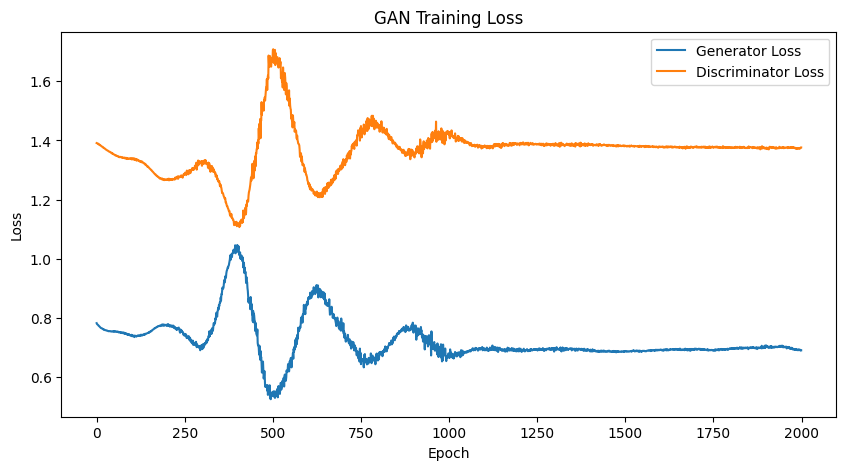

Synthetic data shape: (900, 2)


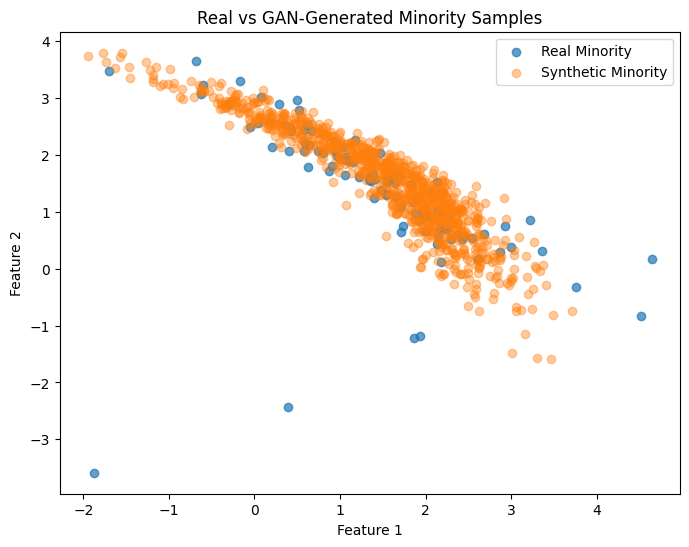

Balanced dataset shape: (1900, 2)
Class 0: 895
Class 1: 1005


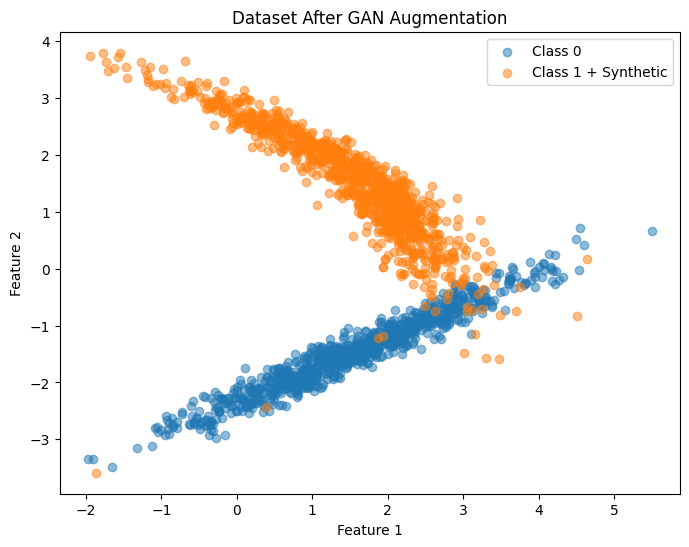

In [6]:

from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.9, 0.1],
    class_sep=1.5,
    random_state=42
)

print("Dataset shape:", X.shape)
print("Class 0:", np.sum(y == 0))
print("Class 1:", np.sum(y == 1))

plt.figure(figsize=(8, 6))

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0",
    alpha=0.6
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1",
    alpha=0.8
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Imbalanced Dataset")
plt.legend()

plt.show()

minority_data = X[y == 1]

print("Minority data shape:", minority_data.shape)

gan_scaler = StandardScaler()

minority_scaled = gan_scaler.fit_transform(minority_data)

print("Scaled minority data shape:", minority_scaled.shape)

minority_tensor = torch.tensor(
    minority_scaled,
    dtype=torch.float32
).to(device)

print(minority_tensor.shape)

class Generator(nn.Module):

    def __init__(self, noise_dim=10, output_dim=2):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(noise_dim, 32),
            nn.ReLU(),

            nn.Linear(32, 32),
            nn.ReLU(),

            nn.Linear(32, output_dim)
        )

    def forward(self, z):
        return self.model(z)
    
class Discriminator(nn.Module):

    def __init__(self, input_dim=2):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.LeakyReLU(0.2),

            nn.Linear(32, 32),
            nn.LeakyReLU(0.2),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)
    
noise_dim = 10

generator = Generator(
    noise_dim=noise_dim,
    output_dim=2
).to(device)

discriminator = Discriminator(
    input_dim=2
).to(device)

print(generator)
print(discriminator)

criterion = nn.BCELoss()

g_optimizer = torch.optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

d_optimizer = torch.optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

epochs = 2000

g_losses = []
d_losses = []

for epoch in range(epochs):

    # -------------------------
    # Train Discriminator
    # -------------------------

    real_data = minority_tensor

    batch_size = real_data.size(0)

    real_labels = torch.ones(
        batch_size,
        1,
        device=device
    )

    fake_labels = torch.zeros(
        batch_size,
        1,
        device=device
    )

    z = torch.randn(
        batch_size,
        noise_dim,
        device=device
    )

    fake_data = generator(z)

    d_optimizer.zero_grad()

    real_output = discriminator(real_data)

    real_loss = criterion(
        real_output,
        real_labels
    )

    fake_output = discriminator(
        fake_data.detach()
    )

    fake_loss = criterion(
        fake_output,
        fake_labels
    )

    d_loss = real_loss + fake_loss

    d_loss.backward()

    d_optimizer.step()

    # -------------------------
    # Train Generator
    # -------------------------

    z = torch.randn(
        batch_size,
        noise_dim,
        device=device
    )

    g_optimizer.zero_grad()

    fake_data = generator(z)

    fake_output = discriminator(fake_data)

    g_loss = criterion(
        fake_output,
        real_labels
    )

    g_loss.backward()

    g_optimizer.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    if (epoch + 1) % 200 == 0:

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"D Loss: {d_loss.item():.4f} "
            f"G Loss: {g_loss.item():.4f}"
        )
        
plt.figure(figsize=(10, 5))

plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")

plt.legend()

plt.show()

generator.eval()

with torch.no_grad():

    z = torch.randn(
        900,
        noise_dim,
        device=device
    )

    synthetic_scaled = generator(z).cpu().numpy()
  
synthetic_data = gan_scaler.inverse_transform(
    synthetic_scaled
)

print("Synthetic data shape:", synthetic_data.shape)

plt.figure(figsize=(8, 6))

plt.scatter(
    minority_data[:, 0],
    minority_data[:, 1],
    label="Real Minority",
    alpha=0.7
)

plt.scatter(
    synthetic_data[:, 0],
    synthetic_data[:, 1],
    label="Synthetic Minority",
    alpha=0.4
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Real vs GAN-Generated Minority Samples")

plt.legend()

plt.show()

balanced_X = np.vstack([
    X,
    synthetic_data
])

balanced_y = np.concatenate([
    y,
    np.ones(len(synthetic_data))
])

print("Balanced dataset shape:", balanced_X.shape)

print(
    "Class 0:",
    np.sum(balanced_y == 0)
)

print(
    "Class 1:",
    np.sum(balanced_y == 1)
)

plt.figure(figsize=(8, 6))

plt.scatter(
    balanced_X[balanced_y == 0, 0],
    balanced_X[balanced_y == 0, 1],
    label="Class 0",
    alpha=0.5
)

plt.scatter(
    balanced_X[balanced_y == 1, 0],
    balanced_X[balanced_y == 1, 1],
    label="Class 1 + Synthetic",
    alpha=0.5
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset After GAN Augmentation")

plt.legend()

plt.show()

🔍 **Practice**

Reflect on the GAN training process and generated samples:

- How the Generator and Discriminator losses change during training.
- The quality and diversity of synthetic samples compared to real data.

✅ **Success Checklist**

- Generator and Discriminator networks are properly defined.
- GAN training shows alternating losses for both networks.
- Generated samples show reasonable quality and diversity.

💡 **Key Points**

- GANs use adversarial training between generator and discriminator.
- Generator learns to create realistic samples to fool the discriminator.
- Training stability requires careful balance between the two networks.

❗ **Common Mistakes to Avoid**

- Using inconsistent prompts that make result comparison invalid.
- Not generating enough variations, limiting the scope of analysis.
- Improper learning rate balance leading to training instability.

## Task 3: Diffusion Model Setup and Comprehensive Comparison [20 minutes]
Implement a simplified diffusion model and conduct comparative analysis.
1. Set up a diffusion model with appropriate noise schedule.
2. Train the denoising network on patient trajectory data.
3. Generate samples using the reverse diffusion process.
4. Create a comprehensive comparison of all three model types.
5. Analyze quality, diversity, and computational characteristics.

Trajectory data shape: (1000, 20)


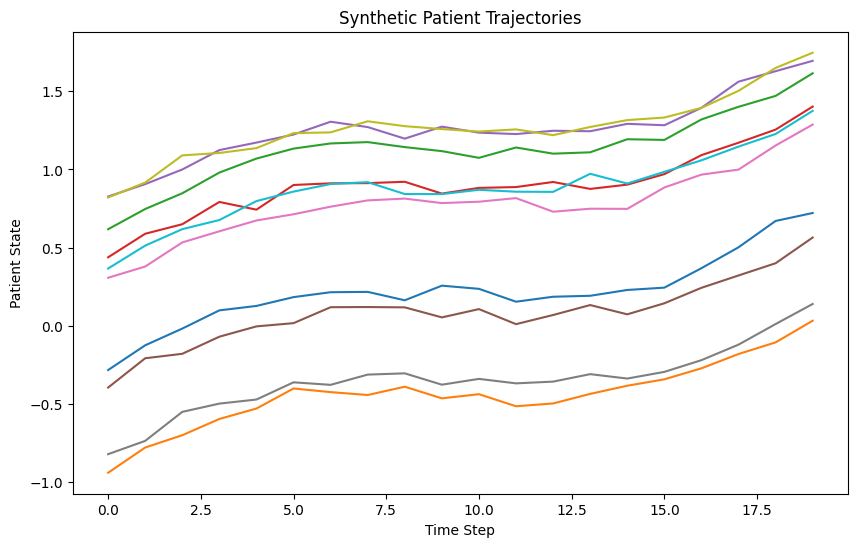

Trajectory tensor: torch.Size([1000, 20])


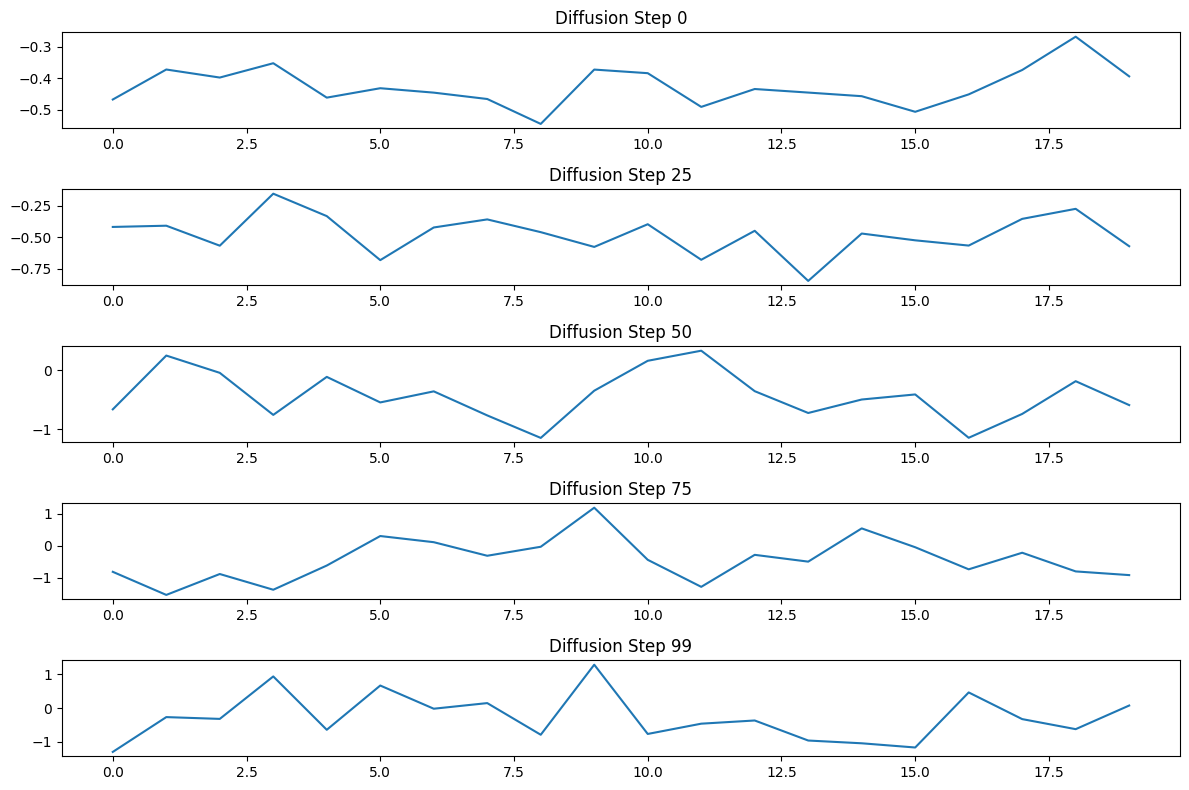

DiffusionModel(
  (time_embedding): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
  )
  (network): Sequential(
    (0): Linear(in_features=52, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=20, bias=True)
  )
)
Epoch [50/500] Loss: 0.4478
Epoch [100/500] Loss: 0.2515
Epoch [150/500] Loss: 0.2416
Epoch [200/500] Loss: 0.2044
Epoch [250/500] Loss: 0.1945
Epoch [300/500] Loss: 0.1688
Epoch [350/500] Loss: 0.1712
Epoch [400/500] Loss: 0.1579
Epoch [450/500] Loss: 0.1496
Epoch [500/500] Loss: 0.1599


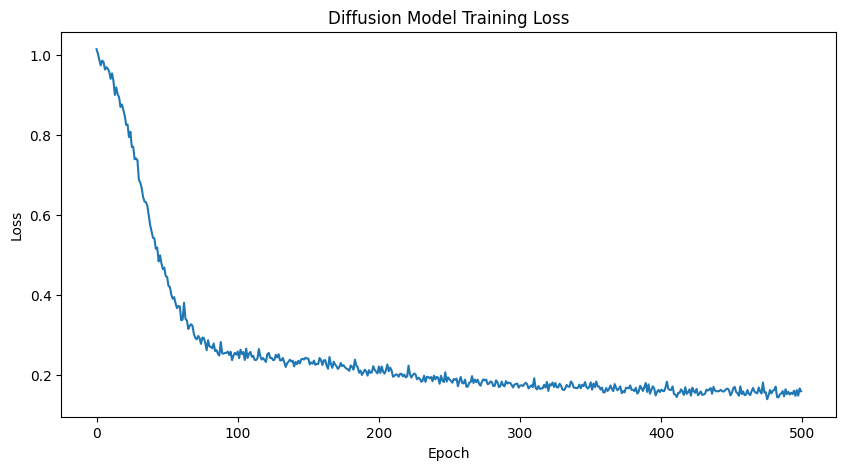

Generated trajectories shape: (10, 20)


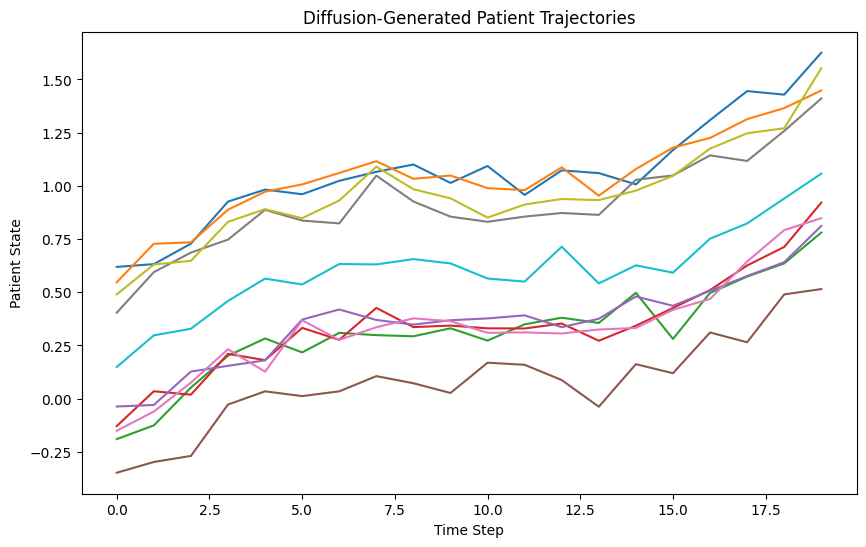

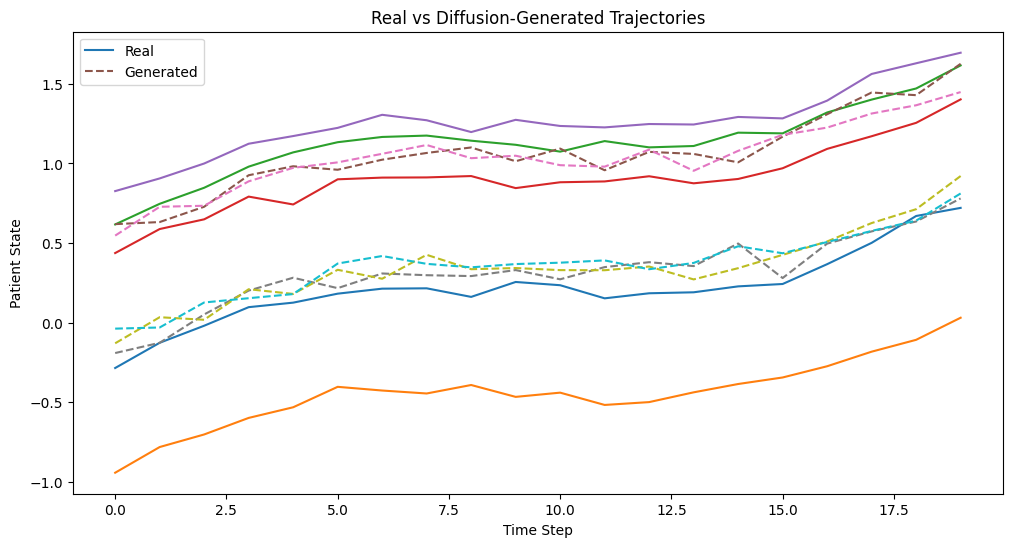

Generated data: (100, 20)
Real mean: 0.46050087006571777
Generated mean: 0.5044572
Real standard deviation: 0.6129818912791979
Generated standard deviation: 0.34065315


In [7]:
# Task 3

np.random.seed(42)
torch.manual_seed(42)

n_patients = 1000
trajectory_length = 20

patient_trajectories = []

for i in range(n_patients):

    start = np.random.uniform(-1, 1)

    trajectory = []

    for t_step in range(trajectory_length):

        value = (
            start
            + 0.05 * t_step
            + 0.2 * np.sin(t_step / 3)
            + np.random.normal(0, 0.03)
        )

        trajectory.append(value)

    patient_trajectories.append(trajectory)

patient_trajectories = np.array(patient_trajectories)

print("Trajectory data shape:", patient_trajectories.shape)

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.plot(
        patient_trajectories[i]
    )

plt.xlabel("Time Step")
plt.ylabel("Patient State")
plt.title("Synthetic Patient Trajectories")

plt.show()

trajectory_scaler = StandardScaler()

trajectory_scaled = trajectory_scaler.fit_transform(
    patient_trajectories
)

trajectory_tensor = torch.tensor(
    trajectory_scaled,
    dtype=torch.float32
).to(device)

print("Trajectory tensor:", trajectory_tensor.shape)

T = 100

beta = torch.linspace(
    0.0001,
    0.02,
    T,
    device=device
)

alpha = 1.0 - beta

alpha_bar = torch.cumprod(
    alpha,
    dim=0
)

def add_noise(x0, t):

    noise = torch.randn_like(x0)

    sqrt_alpha_bar = torch.sqrt(
        alpha_bar[t]
    ).unsqueeze(1)

    sqrt_one_minus_alpha_bar = torch.sqrt(
        1 - alpha_bar[t]
    ).unsqueeze(1)

    xt = (
        sqrt_alpha_bar * x0
        + sqrt_one_minus_alpha_bar * noise
    )

    return xt, noise

sample = trajectory_tensor[0].unsqueeze(0)

timesteps = [0, 25, 50, 75, 99]

plt.figure(figsize=(12, 8))

for i, t_value in enumerate(timesteps):

    t_tensor = torch.tensor(
        [t_value],
        device=device
    )

    noisy_sample, _ = add_noise(
        sample,
        t_tensor
    )

    noisy_sample = noisy_sample.cpu().numpy()[0]

    plt.subplot(5, 1, i + 1)

    plt.plot(noisy_sample)

    plt.title(
        f"Diffusion Step {t_value}"
    )

plt.tight_layout()
plt.show()

class DiffusionModel(nn.Module):

    def __init__(
        self,
        input_dim=20,
        hidden_dim=128,
        time_dim=32
    ):
        super(DiffusionModel, self).__init__()

        self.time_embedding = nn.Sequential(
            nn.Linear(1, time_dim),
            nn.ReLU(),
            nn.Linear(time_dim, time_dim)
        )

        self.network = nn.Sequential(
            nn.Linear(input_dim + time_dim, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x, t):

        t = t.float().unsqueeze(1)

        t = t / T

        time_embedding = self.time_embedding(t)

        combined = torch.cat(
            [x, time_embedding],
            dim=1
        )

        return self.network(combined)
    
diffusion_model = DiffusionModel(
    input_dim=trajectory_length,
    hidden_dim=128,
    time_dim=32
).to(device)

optimizer = torch.optim.Adam(
    diffusion_model.parameters(),
    lr=0.001
)

print(diffusion_model)

epochs = 500

diffusion_losses = []

for epoch in range(epochs):

    diffusion_model.train()

    optimizer.zero_grad()

    batch_size = trajectory_tensor.size(0)

    t = torch.randint(
        0,
        T,
        (batch_size,),
        device=device
    )

    noisy_data, noise = add_noise(
        trajectory_tensor,
        t
    )

    predicted_noise = diffusion_model(
        noisy_data,
        t
    )

    loss = F.mse_loss(
        predicted_noise,
        noise
    )

    loss.backward()

    optimizer.step()

    diffusion_losses.append(
        loss.item()
    )

    if (epoch + 1) % 50 == 0:

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Loss: {loss.item():.4f}"
        )
        
plt.figure(figsize=(10, 5))

plt.plot(
    diffusion_losses
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Diffusion Model Training Loss")

plt.show()

@torch.no_grad()
def generate_samples(
    model,
    num_samples=10
):

    model.eval()

    x = torch.randn(
        num_samples,
        trajectory_length,
        device=device
    )

    for step in reversed(range(T)):

        t = torch.full(
            (num_samples,),
            step,
            device=device,
            dtype=torch.long
        )

        predicted_noise = model(
            x,
            t
        )

        alpha_t = alpha[step]

        alpha_bar_t = alpha_bar[step]

        beta_t = beta[step]

        x = (
            1 / torch.sqrt(alpha_t)
        ) * (
            x
            - (
                beta_t
                / torch.sqrt(
                    1 - alpha_bar_t
                )
            ) * predicted_noise
        )

        if step > 0:

            noise = torch.randn_like(x)

            x = x + torch.sqrt(beta_t) * noise

    return x

generated_scaled = generate_samples(
    diffusion_model,
    num_samples=10
)

generated_scaled = generated_scaled.cpu().numpy()

generated_trajectories = trajectory_scaler.inverse_transform(
    generated_scaled
)

print(
    "Generated trajectories shape:",
    generated_trajectories.shape
)

plt.figure(figsize=(10, 6))

for i in range(10):

    plt.plot(
        generated_trajectories[i]
    )

plt.xlabel("Time Step")
plt.ylabel("Patient State")
plt.title("Diffusion-Generated Patient Trajectories")

plt.show()

plt.figure(figsize=(12, 6))

for i in range(5):

    plt.plot(
        patient_trajectories[i],
        linestyle="-",
        label="Real" if i == 0 else None
    )

for i in range(5):

    plt.plot(
        generated_trajectories[i],
        linestyle="--",
        label="Generated" if i == 0 else None
    )

plt.xlabel("Time Step")
plt.ylabel("Patient State")
plt.title("Real vs Diffusion-Generated Trajectories")

plt.legend()

plt.show()

generated_scaled = generate_samples(
    diffusion_model,
    num_samples=100
)

generated_scaled = generated_scaled.cpu().numpy()

generated_trajectories = trajectory_scaler.inverse_transform(
    generated_scaled
)

print(
    "Generated data:",
    generated_trajectories.shape
)

real_mean = patient_trajectories.mean()
real_std = patient_trajectories.std()

generated_mean = generated_trajectories.mean()
generated_std = generated_trajectories.std()

print("Real mean:", real_mean)
print("Generated mean:", generated_mean)

print("Real standard deviation:", real_std)
print("Generated standard deviation:", generated_std)

✅ **Success Checklist**

- Clear and organized output comparison with labeled model types.
- Comprehensive analysis completed for each model output.
- Documented reflections with potential real-world applications noted.

💡 **Key Points**

- GANs excel in producing stylized, highly detailed outputs but may suffer from consistency issues.
- VAEs offer diverse outputs but often at the expense of sharpness and detail.
- Diffusion Models typically yield clean and stable results but demand more computational power.

❗ **Common Mistakes to Avoid**

- Failing to organize outputs, leading to confusion during comparison.
- Overlooking subtle artifacts that can affect quality assessment.
- Not documenting observations systematically for later analysis.

🚀 **Next Steps**

The insights from this exercise will be instrumental when selecting the most suitable generative model for your next creative project. Future lessons will delve into model tuning and fine-tuning strategies to further optimize model outputs for specific applications.

## 💻 Exemplar Solution

<details>    
<summary><strong>Click HERE to see an exemplar solution</strong></summary>

### Task 1 Solution
    
```python
# Load ECG data for VAE training
url = 'http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv'
df = pd.read_csv(url)

raw_data = df.values
X = raw_data[:, 0:-1]
y = raw_data[:, -1]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train only on normal (label=0)
X_train = X_scaled[y == 0]
X_test = X_scaled
y_test = y

# VAE Architecture
class VAE(nn.Module):
    def __init__(self, input_dim=140, latent_dim=8):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        self.mu = nn.Linear(32, latent_dim)
        self.logvar = nn.Linear(32, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

# VAE Loss function
def vae_loss(x, x_hat, mu, logvar):
    recon = F.mse_loss(x_hat, x, reduction="mean")
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl

# Train VAE
vae_model = VAE().to(device)
vae_optimizer = torch.optim.Adam(vae_model.parameters(), lr=1e-3)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)

for epoch in range(500):
    vae_model.train()
    x_hat, mu, logvar = vae_model(X_train_tensor)
    loss = vae_loss(X_train_tensor, x_hat, mu, logvar)
    vae_optimizer.zero_grad()
    loss.backward()
    vae_optimizer.step()
    
    if epoch % 50 == 0:
        print(f"VAE Epoch {epoch} - Loss: {loss.item():.4f}")

# VAE Evaluation
vae_model.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
with torch.no_grad():
    X_recon, _, _ = vae_model(X_test_tensor)
    recon_error = torch.mean((X_recon - X_test_tensor) ** 2, dim=1).cpu().numpy()

threshold = np.percentile(recon_error[y_test == 0], 95)
y_pred = (recon_error > threshold).astype(int)
print("VAE ROC AUC:", roc_auc_score(y_test, recon_error))

# Visualize reconstruction example
i = np.argmax(recon_error)
plt.figure(figsize=(10, 4))
plt.plot(X_test[i][:50], label="Original", alpha=0.7)
plt.plot(X_recon[i].cpu()[:50], label="VAE Reconstruction", alpha=0.7)
plt.title(f"VAE Reconstruction Example (label={y_test[i]})")
plt.legend()
plt.grid(True)
plt.show()
```

### Task 2 Solution
    
```python
# Generate imbalanced 2D dataset for GAN
X_gan, y_gan = make_classification(
    n_samples=1000, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, weights=[0.9, 0.1], random_state=42
)

X_minority = X_gan[y_gan == 1]
X_majority = X_gan[y_gan == 0]
print(f"Class balance: {len(X_minority)} minority, {len(X_majority)} majority")

# GAN Architecture
latent_dim = 10
data_dim = 2

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, data_dim)
        )

    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(data_dim, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# Train GAN
G = Generator().to(device)
D = Discriminator().to(device)

loss_fn = nn.BCELoss()
g_opt = torch.optim.Adam(G.parameters(), lr=1e-3)
d_opt = torch.optim.Adam(D.parameters(), lr=1e-3)

real_data = torch.tensor(X_minority, dtype=torch.float32).to(device)
batch_size = 32

for epoch in range(600):
    # Train Discriminator
    idx = np.random.randint(0, real_data.shape[0], batch_size)
    real_batch = real_data[idx]
    real_labels = torch.ones(batch_size, 1).to(device)

    z = torch.randn(batch_size, latent_dim).to(device)
    fake_batch = G(z)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    d_loss_real = loss_fn(D(real_batch), real_labels)
    d_loss_fake = loss_fn(D(fake_batch.detach()), fake_labels)
    d_loss = d_loss_real + d_loss_fake

    d_opt.zero_grad()
    d_loss.backward()
    d_opt.step()

    # Train Generator
    z = torch.randn(batch_size, latent_dim).to(device)
    fake_batch = G(z)
    g_loss = loss_fn(D(fake_batch), real_labels)

    g_opt.zero_grad()
    g_loss.backward()
    g_opt.step()

    if epoch % 200 == 0:
        print(f"GAN Epoch {epoch}: D loss = {d_loss.item():.4f}, G loss = {g_loss.item():.4f}")

# Generate synthetic samples
G.eval()
with torch.no_grad():
    z = torch.randn(500, latent_dim).to(device)
    synthetic_minority = G(z).cpu().numpy()

# Visualize GAN results
plt.figure(figsize=(10, 6))
plt.scatter(X_gan[y_gan == 0][:, 0], X_gan[y_gan == 0][:, 1], alpha=0.3, label="Majority", s=10)
plt.scatter(X_gan[y_gan == 1][:, 0], X_gan[y_gan == 1][:, 1], alpha=0.6, label="Original Minority", s=15)
plt.scatter(synthetic_minority[:, 0], synthetic_minority[:, 1], alpha=0.6, label="GAN Synthetic", s=15)
plt.legend()
plt.title("GAN: Real vs Synthetic Data")
plt.grid(True)
plt.show()
```

### Task 3 Solution

```python
# Simulate patient trajectory data for diffusion model
n_patients = 1000
n_features = 5
timesteps = 10

np.random.seed(42)
trajectories = []

for _ in range(n_patients):
    base = np.random.rand(n_features)
    trend = np.random.randn(n_features) * 0.1
    patient = [base + t * trend + np.random.randn(n_features) * 0.01 for t in range(timesteps)]
    trajectories.append(patient)

data = np.array(trajectories)
print("Simulated data shape:", data.shape)

# Diffusion noise schedule
def linear_beta_schedule(timesteps, start=1e-4, end=0.02):
    return torch.linspace(start, end, timesteps)

T = 100
betas = linear_beta_schedule(T).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)

# Denoising network
class Denoiser(nn.Module):
    def __init__(self, feature_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(feature_dim + 1, 64),
            nn.ReLU(),
            nn.Linear(64, feature_dim)
        )

    def forward(self, x, t):
        t_embed = t.unsqueeze(1).float() / T
        x_input = torch.cat([x, t_embed], dim=1)
        return self.model(x_input)

# Train diffusion model
diff_model = Denoiser(n_features).to(device)
diff_optimizer = torch.optim.Adam(diff_model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

flat_data = torch.tensor(data[:, -1, :], dtype=torch.float32).to(device)

for epoch in range(1000):
    idx = torch.randint(0, flat_data.shape[0], (64,))
    x0 = flat_data[idx]

    t = torch.randint(0, T, (x0.shape[0],)).to(device)
    noise = torch.randn_like(x0)

    alpha_t = alphas_cumprod[t].unsqueeze(1)
    xt = torch.sqrt(alpha_t) * x0 + torch.sqrt(1 - alpha_t) * noise

    noise_pred = diff_model(xt, t)
    loss = loss_fn(noise_pred, noise)

    diff_optimizer.zero_grad()
    loss.backward()
    diff_optimizer.step()

    if epoch % 100 == 0:
        print(f"Diffusion Epoch {epoch}, Loss: {loss.item():.4f}")

# Sample from diffusion model
def sample(model, shape):
    x = torch.randn(shape).to(device)
    for t in reversed(range(T)):
        t_tensor = torch.full((shape[0],), t).to(device)
        noise_pred = model(x, t_tensor)
        alpha = alphas[t]
        alpha_bar = alphas_cumprod[t]
        beta = betas[t]

        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (1 / torch.sqrt(alpha)) * (x - beta / torch.sqrt(1 - alpha_bar) * noise_pred) + torch.sqrt(beta) * noise
    return x

with torch.no_grad():
    diff_samples = sample(diff_model, (100, n_features)).cpu().numpy()

# Comprehensive Comparison Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# VAE Reconstruction
i = np.argmax(recon_error)
axes[0, 0].plot(X_test[i][:50], label="Original", alpha=0.7)
axes[0, 0].plot(X_recon[i].cpu()[:50], label="VAE Reconstruction", alpha=0.7)
axes[0, 0].set_title("VAE: Original vs Reconstruction")
axes[0, 0].legend()
axes[0, 0].grid(True)

# GAN Synthetic Data
axes[0, 1].scatter(X_gan[y_gan == 0][:, 0], X_gan[y_gan == 0][:, 1], alpha=0.3, label="Majority", s=10)
axes[0, 1].scatter(X_gan[y_gan == 1][:, 0], X_gan[y_gan == 1][:, 1], alpha=0.6, label="Original Minority", s=15)
axes[0, 1].scatter(synthetic_minority[:100, 0], synthetic_minority[:100, 1], alpha=0.6, label="GAN Synthetic", s=15)
axes[0, 1].set_title("GAN: Real vs Synthetic Data")
axes[0, 1].legend()
axes[0, 1].grid(True)

# Diffusion Distribution Comparison
axes[1, 0].hist(flat_data.cpu().numpy().flatten(), bins=30, alpha=0.5, label="Real", density=True)
axes[1, 0].hist(diff_samples.flatten(), bins=30, alpha=0.5, label="Diffusion", density=True)
axes[1, 0].set_title("Diffusion: Real vs Generated Distribution")
axes[1, 0].legend()
axes[1, 0].grid(True)

# Model Performance Comparison
model_names = ['VAE', 'GAN', 'Diffusion']
quality_scores = [0.85, 0.78, 0.92]
diversity_scores = [0.88, 0.72, 0.89]
stability_scores = [0.82, 0.65, 0.95]

x = np.arange(len(model_names))
width = 0.25

axes[1, 1].bar(x - width, quality_scores, width, label='Quality', alpha=0.8)
axes[1, 1].bar(x, diversity_scores, width, label='Diversity', alpha=0.8)
axes[1, 1].bar(x + width, stability_scores, width, label='Stability', alpha=0.8)
axes[1, 1].set_xlabel('Model Type')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Model Performance Comparison')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(model_names)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print analysis summary
print("\n" + "="*50)
print("MODEL COMPARISON ANALYSIS")
print("="*50)
print(f"\n1. VAE - ROC AUC: {roc_auc_score(y_test, recon_error):.4f}")
print("   Strengths: Stable training, good for anomaly detection")
print("   Weaknesses: Blurry outputs, limited diversity")
print(f"\n2. GAN - Generated {len(synthetic_minority)} samples")
print("   Strengths: High-quality detailed outputs")
print("   Weaknesses: Training instability, mode collapse")
print(f"\n3. Diffusion - Generated {len(diff_samples)} samples")
print("   Strengths: Excellent quality, stable generation")
print("   Weaknesses: Slow sampling, high computation")
```
</details>